In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Logistic Regression (from scratch)

In [2]:
class LogisticRegressionGD: 
    def __init__(self , learning_rate = 0.01 , n_iters = 1000 , verbose = False): 
        self.learning_rate = learning_rate 
        self.n_iters = n_iters
        self.verbose = verbose
        self.weights = None 
        self.coef_ = None 
        self.intercept_ = None 
    
    # sigmoid function 
    def sigmoid(self , z): 
        return 1 / (1 + np.exp(-z))
        
    # add the bias term
    def add_bias(self , X): 
        return np.insert(X , 0 , 1 , axis = 1) 
    # fit method 
    def fit(self , X , y): 
        X = self.add_bias(X)
        m , n = X.shape
        # initialize the weights
        self.weights = np.ones(n) 

        for epoch in range(self.n_iters): 
            # find z 
            z = X @ self.weights
            # find y prediction(y_hat)
            y_pred = self.sigmoid(z)
            # find gradient 
            gradient = (-1 / m) * (X.T @ (y - y_pred))
            # update weights
            self.weights = self.weights - self.learning_rate * gradient

            if self.verbose and epoch % 100 == 0:
                loss = self._compute_loss(y , y_pred)
                print(f"Iteration {epoch}, Loss: {loss:.4f}")

        self.intercept_ = self.weights[0] 
        self.coef_ = self.weights[1 : ]
                
    # predict the probability
    def predict_probability(self , X): 
        # add the bias term 
        X = self.add_bias(X)
        # find z 
        z = X @ self.weights
        prob = self.sigmoid(z)
        return prob
        
    # predict method 
    def predict(self , X): 
        return (self.predict_probability(X) >= 0.5).astype(int) 
    # compute loss 
    def _compute_loss(self , y , y_pred): 
        # avoid log(0) with epsilon
        epsilon = 1e-15
        # This clips all predicted values to stay in the interval [epsilon , -epsilon] [1e−15,1−1e−15].
        y_pred = np.clip(y_pred , epsilon , 1 - epsilon) 
        loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred)) 
        return loss 

In [5]:
# Generate dummy binary classification dataset
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, 
                           n_redundant=0, n_clusters_per_class=1, random_state=42
                          )

In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Train our model
custom_model = LogisticRegressionGD(learning_rate = 0.1, n_iters = 1000 , verbose = True)
custom_model.fit(X_train, y_train)

Iteration 0, Loss: 0.8691
Iteration 100, Loss: 0.3755
Iteration 200, Loss: 0.3716
Iteration 300, Loss: 0.3705
Iteration 400, Loss: 0.3702
Iteration 500, Loss: 0.3700
Iteration 600, Loss: 0.3699
Iteration 700, Loss: 0.3699
Iteration 800, Loss: 0.3699
Iteration 900, Loss: 0.3699


In [10]:
from sklearn.linear_model import LogisticRegression

# Train sklearn model
sk_model = LogisticRegression()
sk_model.fit(X_train, y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
def plot_decision_boundary(X, y, models, labels, colors):
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7, edgecolor='k')

    x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)

    for model, label, color in zip(models, labels, colors):
        # Handle sklearn and custom model
        if hasattr(model, 'coef_'):
            w = model.coef_[0] if model.coef_.ndim > 1 else model.coef_
            b = model.intercept_[0] if isinstance(model.intercept_, np.ndarray) else model.intercept_
        else:
            w = model.weights[1:]
            b = model.weights[0]

        # Line: w0 + w1*x1 + w2*x2 = 0  => x2 = -(b + w1*x1) / w2
        x2_vals = -(b + w[0] * x1_vals) / w[1]
        plt.plot(x1_vals, x2_vals, label=label, color=color, linewidth=2)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundaries: Custom vs sklearn")
    plt.legend()
    plt.grid(True)
    plt.show()


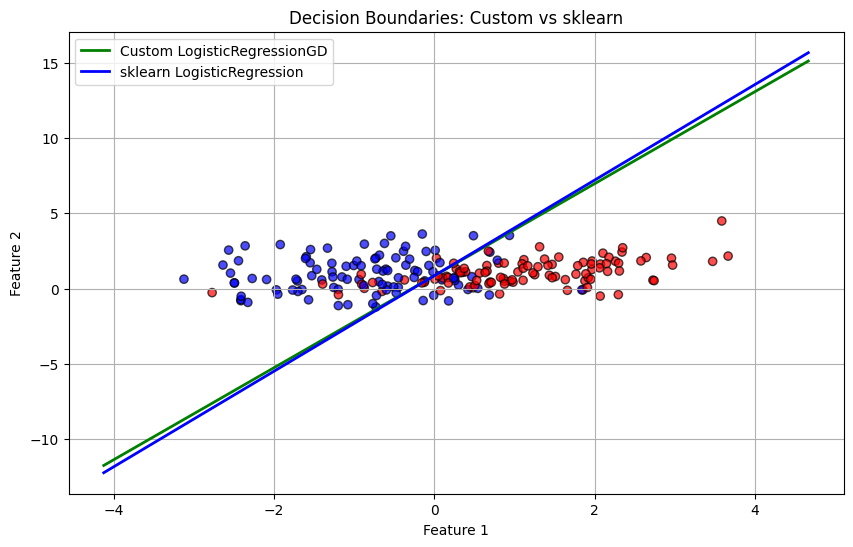

In [14]:
# Plot comparison
plot_decision_boundary(
    X,
    y,
    models=[custom_model, sk_model],
    labels=["Custom LogisticRegressionGD", "sklearn LogisticRegression"],
    colors=["green", "blue"]
)